# Notebook 11 — Comparación de Versiones del Modelo HemoVet

**Fase 3 · Módulo 3G** — Evaluación comparativa de todas las versiones del modelo XGBoost multilabel en val y test set, con métricas detalladas (F1, Precisión, Recall, PR-AUC, TP/FP/FN/TN) y visualización por colores según rendimiento.

**Entrada:** `models/best_model*.pkl`, `data/processed/{val,test}.csv`, archivos de thresholds por versión  
**Salida:** Tablas HTML con color-coding + `outputs/comparacion_modelos.csv`

| Versión | Descripción | Features | Thresholds |
|---|---|---|---|
| **v1** | XGBoost inicial, sin reticulocitos | 38 | F1-max en val |
| **v3** | XGBoost con reticulocitos + Platt scaling | 43 | F1-max en val |
| **v3.1** | v3 + ajuste clínico de umbrales (S1–S3) | 43 | Clínico |
| **v4** | v3 + 1213 hemogramas MYTHIC_VET nuevos | 43 | F-beta β=2 |

**Clasificación de etiquetas:**
- **QC Máquina (ML):** QC_REQUIERE_FROTIS
- **Patrones clínicos (ML):** PATRON_INFLAMATORIO, PATRON_LEUCOGRAMA_ESTRES, PATRON_ANEMIA_NO_REGENERATIVA, PATRON_HEMOLISIS_MCHC, PATRON_POLICITEMIA, PATRON_ANEMIA_REGENERATIVA
- **Deterministas (regla):** QC_AGREGADOS_PLAQUETARIOS

**Color-coding en tablas:** Verde >= 0.90 | Amarillo 0.70–0.90 | Rojo < 0.70

### Guia rapida del codigo

- Carga modelos, thresholds y splits para comparar versiones.
- Calcula metricas por etiqueta en validacion y test.
- Genera tablas, heatmaps y conteos de falsos negativos.
- Exporta `outputs/comparacion_modelos.csv` y figuras NB11.


In [1]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
from sklearn.metrics import (
    average_precision_score, f1_score,
    precision_score, recall_score, confusion_matrix,
)

warnings.filterwarnings('ignore')

_cwd = Path.cwd()
PROJECT = _cwd
while PROJECT.name != 'hemogramas-proyectoICC' and PROJECT.parent != PROJECT:
    PROJECT = PROJECT.parent

DATA   = PROJECT / 'data' / 'processed'
MODELS = PROJECT / 'models'
OUT    = PROJECT / 'outputs'
OUT.mkdir(exist_ok=True)

# Categorias de etiquetas
LABEL_META = {
    'QC_REQUIERE_FROTIS':           {'cat': 'QC Maquina'},
    'PATRON_INFLAMATORIO':          {'cat': 'Patron Clinico'},
    'PATRON_LEUCOGRAMA_ESTRES':     {'cat': 'Patron Clinico'},
    'PATRON_ANEMIA_NO_REGENERATIVA':{'cat': 'Patron Clinico'},
    'PATRON_HEMOLISIS_MCHC':        {'cat': 'Patron Clinico'},
    'PATRON_POLICITEMIA':           {'cat': 'Patron Clinico'},
    'PATRON_ANEMIA_REGENERATIVA':   {'cat': 'Patron Clinico'},
    'QC_AGREGADOS_PLAQUETARIOS':    {'cat': 'Determinista'},
}

OFFICIAL_LABELS = [
    'QC_REQUIERE_FROTIS',
    'PATRON_INFLAMATORIO',
    'PATRON_LEUCOGRAMA_ESTRES',
    'PATRON_ANEMIA_NO_REGENERATIVA',
    'PATRON_HEMOLISIS_MCHC',
    'PATRON_POLICITEMIA',
    'PATRON_ANEMIA_REGENERATIVA',
]

print(f'Proyecto: {PROJECT}')

Proyecto: /home/edwinb/tesis/hemogramas-proyectoICC


## 1. Carga de modelos y configuración de versiones

In [2]:
# Cargar features por versión
with open(DATA / 'feature_columns.json') as f:
    FEATURES_V3 = json.load(f)['feature_columns']  # 43 features (v3/v4)

with open(MODELS / 'model_metadata.json') as f:
    FEATURES_V1 = json.load(f)['feature_columns']   # 38 features (v1)

# Cargar modelos
with open(MODELS / 'best_model.pkl',    'rb') as f: model_v1 = pickle.load(f)
with open(MODELS / 'best_model_v3.pkl', 'rb') as f: model_v3 = pickle.load(f)
with open(MODELS / 'best_model_v4.pkl', 'rb') as f: model_v4 = pickle.load(f)

# Thresholds por versión
with open(DATA / 'decision_thresholds.json') as f:
    thr_v1 = json.load(f)['thresholds']
with open(DATA / 'decision_thresholds_v3.json') as f:
    thr_v3 = json.load(f)['thresholds']
with open(DATA / 'decision_thresholds_v3_clinical.json') as f:
    thr_v3c = json.load(f)['thresholds']
with open(DATA / 'decision_thresholds_v4.json') as f:
    thr_v4_raw = json.load(f)['thresholds']

# v4 con ajuste clínico de POLICITEMIA
thr_v4 = dict(thr_v4_raw)
thr_v4['PATRON_POLICITEMIA'] = 0.90

VERSIONS = [
    {'name': 'v1',  'label': 'v1 · XGBoost base\n(38 feat, F1-max)',      'model': model_v1, 'features': FEATURES_V1, 'thr': thr_v1,  'color': '#9b59b6'},
    {'name': 'v3',  'label': 'v3 · XGBoost + Retics\n(43 feat, F1-max)',  'model': model_v3, 'features': FEATURES_V3, 'thr': thr_v3,  'color': '#3498db'},
    {'name': 'v3c', 'label': 'v3.1 · Ajuste clínico\n(S1–S3 thresholds)', 'model': model_v3, 'features': FEATURES_V3, 'thr': thr_v3c, 'color': '#e67e22'},
    {'name': 'v4',  'label': 'v4 · +MYTHIC_VET\n(1213 casos nuevos)',     'model': model_v4, 'features': FEATURES_V3, 'thr': thr_v4,  'color': '#27ae60'},
]

print('Versiones cargadas:')
for v in VERSIONS:
    print(f"  {v['name']:<5} features={len(v['features'])}  labels_en_modelo={len(v['model'])}")

Versiones cargadas:
  v1    features=38  labels_en_modelo=8
  v3    features=43  labels_en_modelo=7
  v3c   features=43  labels_en_modelo=7
  v4    features=43  labels_en_modelo=7


## 2. Cálculo de métricas por versión y split

In [3]:
def compute_metrics(model, features, thresholds, df, labels):
    X = df.reindex(columns=features, fill_value=0.0).values
    rows = []
    for label in labels:
        if label not in df.columns or df[label].sum() == 0:
            continue
        if label not in model:
            continue
        y = df[label].astype(int).values
        prob = model[label].predict_proba(X)[:, 1]
        thr  = thresholds.get(label, 0.5)
        pred = (prob >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        n_pos, n_neg = int(y.sum()), int((1 - y).sum())

        prauc = average_precision_score(y, prob)
        prec  = precision_score(y, pred, zero_division=0)
        rec   = recall_score(y, pred, zero_division=0)
        f1    = f1_score(y, pred, zero_division=0)
        spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        rows.append({
            'label':  label,
            'cat':    LABEL_META.get(label, {}).get('cat', '?'),
            'n_pos':  n_pos,  'n_neg': n_neg,
            'thr':    round(thr, 4),
            'prauc':  round(prauc, 4),
            'f1':     round(f1, 4),
            'prec':   round(prec, 4),
            'rec':    round(rec, 4),
            'spec':   round(spec, 4),
            'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
        })
    return pd.DataFrame(rows)


val_df  = pd.read_csv(DATA / 'val.csv')
test_df = pd.read_csv(DATA / 'test.csv')

all_results = []
for split_name, df in [('val', val_df), ('test', test_df)]:
    for v in VERSIONS:
        mdf = compute_metrics(v['model'], v['features'], v['thr'], df, OFFICIAL_LABELS)
        mdf.insert(0, 'version', v['name'])
        mdf.insert(1, 'split',   split_name)
        all_results.append(mdf)

df_all = pd.concat(all_results, ignore_index=True)
df_all.to_csv(OUT / 'comparacion_modelos.csv', index=False)
print(f'Total filas: {len(df_all)}')
print(f'Guardado: {OUT / "comparacion_modelos.csv"}')

Total filas: 56
Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/comparacion_modelos.csv


## 3. Tabla comparativa — Test Set (resultado oficial)

In [4]:
def color_metric(val, low=0.70, high=0.90):
    if pd.isna(val):
        return ''
    if val >= high:
        return 'background-color: #c8f7c5; color: #1a6b17; font-weight: bold'
    if val >= low:
        return 'background-color: #fef9e7; color: #7d6608'
    return 'background-color: #fadbd8; color: #922b21; font-weight: bold'


def make_comparison_table(split_name):
    df_split = df_all[df_all['split'] == split_name].copy()

    version_order  = ['v1', 'v3', 'v3c', 'v4']
    version_labels = {'v1': 'v1', 'v3': 'v3', 'v3c': 'v3.1', 'v4': 'v4'}

    rows = []
    for label in OFFICIAL_LABELS:
        sub = df_split[df_split['label'] == label]
        if sub.empty:
            continue
        meta  = LABEL_META.get(label, {})
        short = label.replace('PATRON_', '').replace('QC_', '')
        row   = {
            'Categoria': meta.get('cat', ''),
            'Etiqueta':  short,
            'n+':        sub.iloc[0]['n_pos'],
        }
        for ver in version_order:
            r  = sub[sub['version'] == ver]
            vl = version_labels[ver]
            if r.empty:
                for m in ['PR-AUC', 'F1', 'Prec', 'Rec', 'TP', 'FP', 'FN']:
                    row[f'{m}_{vl}'] = np.nan
            else:
                r = r.iloc[0]
                row[f'PR-AUC_{vl}'] = r['prauc']
                row[f'F1_{vl}']     = r['f1']
                row[f'Prec_{vl}']   = r['prec']
                row[f'Rec_{vl}']    = r['rec']
                row[f'TP_{vl}']     = int(r['tp'])
                row[f'FP_{vl}']     = int(r['fp'])
                row[f'FN_{vl}']     = int(r['fn'])
        rows.append(row)

    tbl = pd.DataFrame(rows)

    metric_cols = [c for c in tbl.columns if any(
        c.startswith(m) for m in ['PR-AUC', 'F1', 'Prec', 'Rec']
    )]

    def apply_colors(df):
        styles = pd.DataFrame('', index=df.index, columns=df.columns)
        for col in metric_cols:
            styles[col] = df[col].apply(color_metric)
        return styles

    styled = (
        tbl.style
        .apply(apply_colors, axis=None)
        .format({
            **{c: '{:.4f}' for c in metric_cols},
            **{c: '{:.0f}' for c in tbl.columns if c.startswith(('TP_', 'FP_', 'FN_'))},
        }, na_rep='—')
        .set_table_styles([
            {'selector': 'th', 'props': [('font-size', '11px'), ('text-align', 'center'),
                                          ('background-color', '#2c3e50'), ('color', 'white'),
                                          ('padding', '6px 8px')]},
            {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'center'),
                                          ('padding', '4px 8px'), ('border', '1px solid #ddd')]},
            {'selector': 'tr:hover td', 'props': [('background-color', '#f0f8ff')]},
        ])
        .set_caption(f'<b>Comparacion de versiones — {split_name.upper()} SET</b><br>'
                     '<small>Verde &gt;= 0.90 | Amarillo 0.70–0.90 | Rojo &lt; 0.70</small>')
    )
    return styled


display(make_comparison_table('test'))

,Categoria,Etiqueta,n+,PR-AUC_v1,F1_v1,Prec_v1,Rec_v1,TP_v1,FP_v1,FN_v1,PR-AUC_v3,F1_v3,Prec_v3,Rec_v3,TP_v3,FP_v3,FN_v3,PR-AUC_v3.1,F1_v3.1,Prec_v3.1,Rec_v3.1,TP_v3.1,FP_v3.1,FN_v3.1,PR-AUC_v4,F1_v4,Prec_v4,Rec_v4,TP_v4,FP_v4,FN_v4
0,QC Maquina,REQUIERE_FROTIS,136,0.8503,0.7586,0.9167,0.6471,88,8,48,0.8605,0.7111,0.8989,0.5882,80,9,56,0.8605,0.7111,0.8989,0.5882,80,9,56,0.8455,0.7231,0.7581,0.6912,94,30,42
1,Patron Clinico,INFLAMATORIO,198,0.9937,0.9850,0.9752,0.9949,197,5,1,0.9936,0.9875,0.9801,0.9949,197,4,1,0.9936,0.9875,0.9801,0.9949,197,4,1,0.9931,0.9825,0.9704,0.9949,197,6,1
2,Patron Clinico,LEUCOGRAMA_ESTRES,172,0.9875,0.9623,0.9595,0.9651,166,7,6,0.9861,0.9716,0.9500,0.9942,171,9,1,0.9861,0.9273,0.9684,0.8895,153,5,19,0.9833,0.9653,0.9598,0.9709,167,7,5
3,Patron Clinico,ANEMIA_NO_REGENERATIVA,42,0.8717,0.8140,0.7955,0.8333,35,9,7,0.9853,0.9882,0.9767,1.0000,42,1,0,0.9853,0.9882,0.9767,1.0000,42,1,0,0.9721,0.9882,0.9767,1.0000,42,1,0
4,Patron Clinico,HEMOLISIS_MCHC,48,0.9936,0.9362,0.9565,0.9167,44,2,4,0.9924,0.9362,0.9565,0.9167,44,2,4,0.9924,0.9362,0.9565,0.9167,44,2,4,0.9875,0.9592,0.9400,0.9792,47,3,1
5,Patron Clinico,POLICITEMIA,32,1.0000,0.9153,1.0000,0.8438,27,0,5,1.0000,0.9333,1.0000,0.8750,28,0,4,1.0000,1.0000,1.0000,1.0000,32,0,0,1.0000,1.0000,1.0000,1.0000,32,0,0
6,Patron Clinico,ANEMIA_REGENERATIVA,6,0.1762,0.1667,0.1111,0.3333,2,16,4,0.8860,0.5000,0.3571,0.8333,5,9,1,0.8860,0.5000,0.3571,0.8333,5,9,1,0.8889,0.5000,0.3571,0.8333,5,9,1


## 4. Tabla comparativa — Val Set

In [5]:
display(make_comparison_table('val'))

,Categoria,Etiqueta,n+,PR-AUC_v1,F1_v1,Prec_v1,Rec_v1,TP_v1,FP_v1,FN_v1,PR-AUC_v3,F1_v3,Prec_v3,Rec_v3,TP_v3,FP_v3,FN_v3,PR-AUC_v3.1,F1_v3.1,Prec_v3.1,Rec_v3.1,TP_v3.1,FP_v3.1,FN_v3.1,PR-AUC_v4,F1_v4,Prec_v4,Rec_v4,TP_v4,FP_v4,FN_v4
0,QC Maquina,REQUIERE_FROTIS,130,0.9155,0.8333,0.9091,0.7692,100,10,30,0.9103,0.8255,0.9238,0.7462,97,8,33,0.9103,0.8255,0.9238,0.7462,97,8,33,0.9125,0.8000,0.7467,0.8615,112,38,18
1,Patron Clinico,INFLAMATORIO,175,0.9881,0.9771,0.9771,0.9771,171,4,4,0.9857,0.9771,0.9771,0.9771,171,4,4,0.9857,0.9742,0.9770,0.9714,170,4,5,0.9865,0.9744,0.9716,0.9771,171,5,4
2,Patron Clinico,LEUCOGRAMA_ESTRES,167,0.9817,0.9362,0.9506,0.9222,154,8,13,0.9811,0.9341,0.9341,0.9341,156,11,11,0.9811,0.8610,0.9922,0.7605,127,1,40,0.9820,0.9301,0.9444,0.9162,153,9,14
3,Patron Clinico,ANEMIA_NO_REGENERATIVA,47,0.7608,0.7664,0.6833,0.8723,41,19,6,0.9697,0.9462,0.9565,0.9362,44,2,3,0.9697,0.9348,0.9556,0.9149,43,2,4,0.9657,0.9362,0.9362,0.9362,44,3,3
4,Patron Clinico,HEMOLISIS_MCHC,80,0.9852,0.9620,0.9744,0.9500,76,2,4,0.9834,0.9682,0.9870,0.9500,76,1,4,0.9834,0.9682,0.9870,0.9500,76,1,4,0.9761,0.9500,0.9500,0.9500,76,4,4
5,Patron Clinico,POLICITEMIA,27,1.0000,1.0000,1.0000,1.0000,27,0,0,1.0000,1.0000,1.0000,1.0000,27,0,0,1.0000,1.0000,1.0000,1.0000,27,0,0,1.0000,1.0000,1.0000,1.0000,27,0,0
6,Patron Clinico,ANEMIA_REGENERATIVA,15,0.5034,0.5714,0.5000,0.6667,10,10,5,0.9419,0.8750,0.8235,0.9333,14,3,1,0.9419,0.8750,0.8235,0.9333,14,3,1,0.9539,0.9091,0.8333,1.0000,15,3,0


## 5. Evolución de PR-AUC y F1 por versión

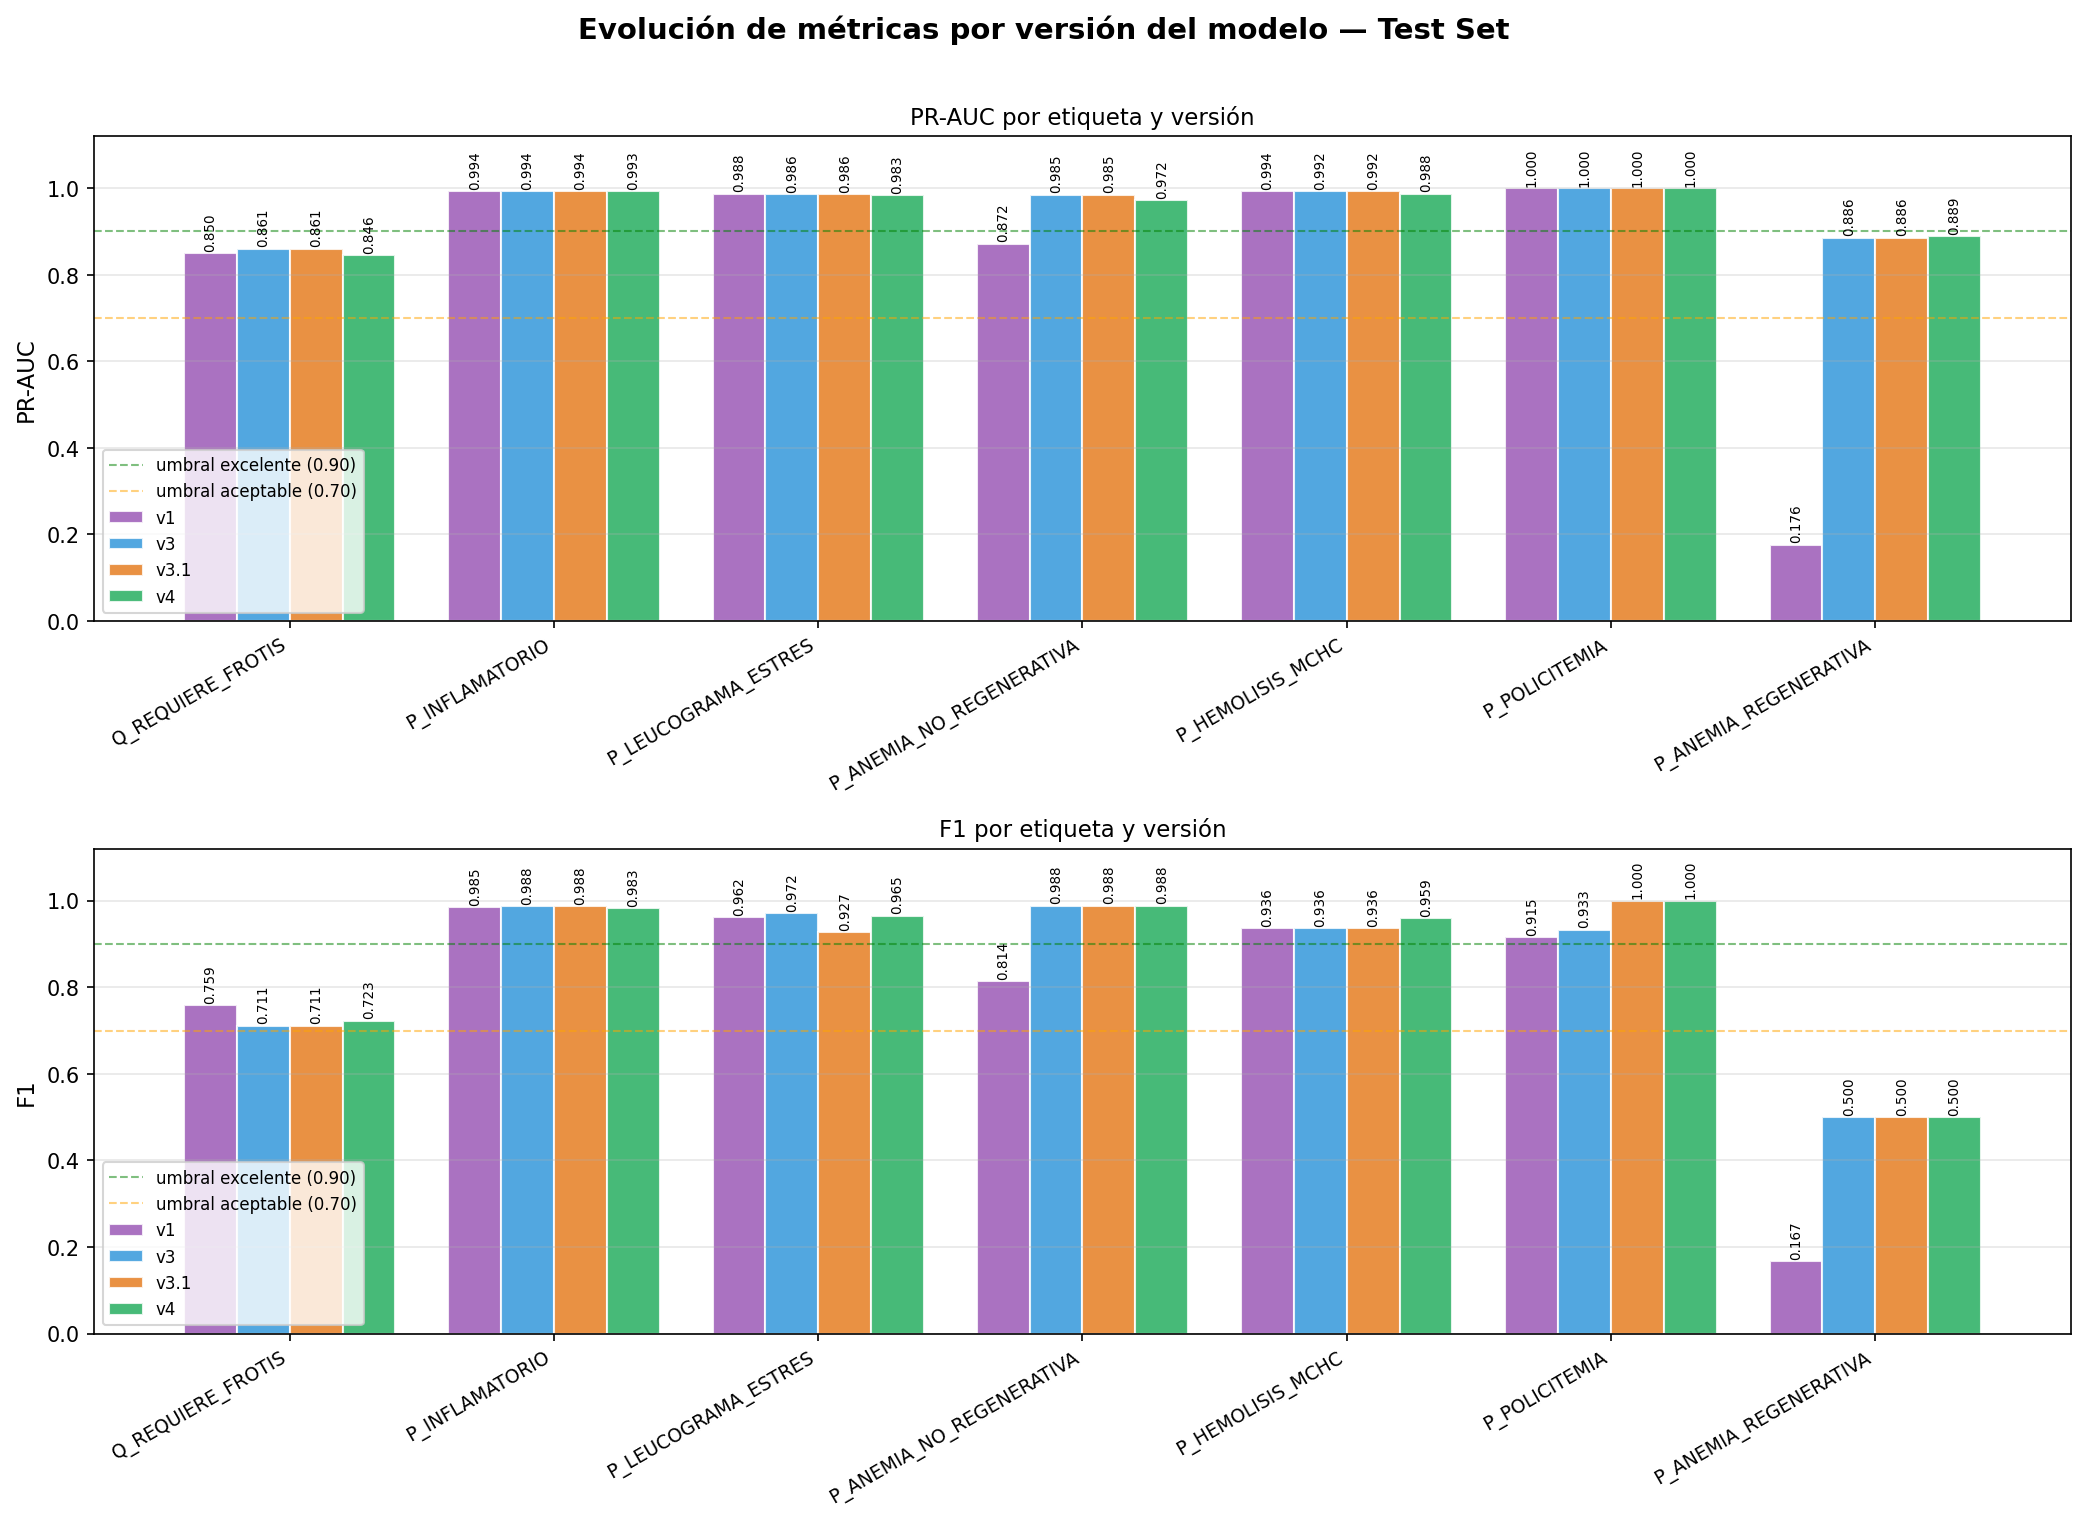

In [6]:
df_test = df_all[df_all['split'] == 'test'].copy()
ver_names = ['v1', 'v3', 'v3c', 'v4']
ver_display = ['v1', 'v3', 'v3.1', 'v4']
colors_ver = ['#9b59b6', '#3498db', '#e67e22', '#27ae60']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Evolución de métricas por versión del modelo — Test Set', fontsize=14, fontweight='bold', y=1.01)

for ax_idx, (metric, title) in enumerate([('prauc', 'PR-AUC'), ('f1', 'F1')]):
    ax = axes[ax_idx]

    label_list  = OFFICIAL_LABELS
    n_labels    = len(label_list)
    n_versions  = len(ver_names)
    x           = np.arange(n_labels)
    width       = 0.20
    offsets     = np.linspace(-(n_versions - 1) / 2, (n_versions - 1) / 2, n_versions) * width

    for j, (ver, vdisp, col) in enumerate(zip(ver_names, ver_display, colors_ver)):
        vals = []
        for label in label_list:
            r = df_test[(df_test['version'] == ver) & (df_test['label'] == label)]
            vals.append(r[metric].values[0] if not r.empty else 0)
        bars = ax.bar(x + offsets[j], vals, width, label=vdisp, color=col, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

    short_labels = [l.replace('PATRON_', 'P_').replace('QC_', 'Q_') for l in label_list]
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(title, fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.axhline(0.90, ls='--', color='green', alpha=0.5, lw=1, label='umbral excelente (0.90)')
    ax.axhline(0.70, ls='--', color='orange', alpha=0.5, lw=1, label='umbral aceptable (0.70)')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'{title} por etiqueta y versión', fontsize=11)

plt.tight_layout()
fig.savefig(OUT / 'nb11_evolucion_metricas.png', dpi=150, bbox_inches='tight')
plt.close(fig)
from IPython.display import Image
display(Image(str(OUT / 'nb11_evolucion_metricas.png')))

## 6. Tabla de confusión acumulada — Test Set

In [7]:
conf_rows = []
for label in OFFICIAL_LABELS:
    meta  = LABEL_META.get(label, {})
    short = label.replace('PATRON_', '').replace('QC_', '')
    row   = {
        'Categoria': meta.get('cat', '')[:16],
        'Etiqueta':  short,
    }
    for ver in ['v1', 'v3', 'v3c', 'v4']:
        vl = {'v1': 'v1', 'v3': 'v3', 'v3c': 'v3.1', 'v4': 'v4'}[ver]
        r  = df_test[(df_test['version'] == ver) & (df_test['label'] == label)]
        if r.empty:
            row[f'TP {vl}'] = '—'
            row[f'FP {vl}'] = '—'
            row[f'FN {vl}'] = '—'
        else:
            r = r.iloc[0]
            row[f'TP {vl}'] = int(r['tp'])
            row[f'FP {vl}'] = int(r['fp'])
            row[f'FN {vl}'] = int(r['fn'])
    conf_rows.append(row)

df_conf = pd.DataFrame(conf_rows)

def style_conf(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for col in df.columns:
        if col.startswith('FN'):
            styles[col] = df[col].apply(
                lambda v: 'background-color:#fadbd8;color:#922b21;font-weight:bold'
                if isinstance(v, int) and v > 0 else ''
            )
        elif col.startswith('FP'):
            styles[col] = df[col].apply(
                lambda v: 'background-color:#fef9e7;color:#7d6608'
                if isinstance(v, int) and v > 3 else ''
            )
        elif col.startswith('TP'):
            styles[col] = df[col].apply(
                lambda v: 'background-color:#c8f7c5;color:#1a6b17'
                if isinstance(v, int) and v > 0 else ''
            )
    return styles

styled_conf = (
    df_conf.style
    .apply(style_conf, axis=None)
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '11px'), ('text-align', 'center'),
                                      ('background-color', '#2c3e50'), ('color', 'white'), ('padding', '5px')]},
        {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'center'),
                                      ('padding', '4px 6px'), ('border', '1px solid #ddd')]},
    ])
    .set_caption('<b>TP / FP / FN por version — Test Set</b><br>'
                 '<small>Verde=TP | Rojo=FN (diagnosticos perdidos) | Amarillo=FP elevado</small>')
)
display(styled_conf)

,Categoria,Etiqueta,TP v1,FP v1,FN v1,TP v3,FP v3,FN v3,TP v3.1,FP v3.1,FN v3.1,TP v4,FP v4,FN v4
0,QC Maquina,REQUIERE_FROTIS,88,8,48,80,9,56,80,9,56,94,30,42
1,Patron Clinico,INFLAMATORIO,197,5,1,197,4,1,197,4,1,197,6,1
2,Patron Clinico,LEUCOGRAMA_ESTRES,166,7,6,171,9,1,153,5,19,167,7,5
3,Patron Clinico,ANEMIA_NO_REGENERATIVA,35,9,7,42,1,0,42,1,0,42,1,0
4,Patron Clinico,HEMOLISIS_MCHC,44,2,4,44,2,4,44,2,4,47,3,1
5,Patron Clinico,POLICITEMIA,27,0,5,28,0,4,32,0,0,32,0,0
6,Patron Clinico,ANEMIA_REGENERATIVA,2,16,4,5,9,1,5,9,1,5,9,1


## 7. Resumen macro por versión

In [8]:
summary_rows = []
ver_display_map = {'v1': 'v1 · XGBoost base', 'v3': 'v3 · +Reticulocitos',
                   'v3c': 'v3.1 · Ajuste clínico', 'v4': 'v4 · +MYTHIC_VET (1213 casos)'}

for split_name in ['val', 'test']:
    df_s = df_all[df_all['split'] == split_name]
    for ver in ['v1', 'v3', 'v3c', 'v4']:
        df_v = df_s[df_s['version'] == ver]
        if df_v.empty:
            continue
        total_fn = int(df_v['fn'].sum())
        total_fp = int(df_v['fp'].sum())
        total_tp = int(df_v['tp'].sum())
        summary_rows.append({
            'Split': split_name.upper(),
            'Versión': ver_display_map[ver],
            'PR-AUC macro': round(df_v['prauc'].mean(), 4),
            'F1 macro':     round(df_v['f1'].mean(), 4),
            'Rec macro':    round(df_v['rec'].mean(), 4),
            'Prec macro':   round(df_v['prec'].mean(), 4),
            'ΣTP': total_tp,
            'ΣFP': total_fp,
            'ΣFN': total_fn,
        })

df_sum = pd.DataFrame(summary_rows)

metric_cols_sum = ['PR-AUC macro', 'F1 macro', 'Rec macro', 'Prec macro']

def apply_sum_colors(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for col in metric_cols_sum:
        styles[col] = df[col].apply(color_metric)
    styles['ΣFN'] = df['ΣFN'].apply(
        lambda v: 'background-color:#fadbd8;color:#922b21;font-weight:bold' if v > 10 else
                  ('background-color:#fef9e7' if v > 3 else 'background-color:#c8f7c5')
    )
    return styles

styled_sum = (
    df_sum.style
    .apply(apply_sum_colors, axis=None)
    .format({c: '{:.4f}' for c in metric_cols_sum})
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '12px'), ('text-align', 'center'),
                                      ('background-color', '#2c3e50'), ('color', 'white'), ('padding', '7px')]},
        {'selector': 'td', 'props': [('font-size', '12px'), ('text-align', 'center'),
                                      ('padding', '5px 10px'), ('border', '1px solid #ddd')]},
    ])
    .set_caption('<b>Resumen macro — todas las versiones</b>')
)
display(styled_sum)

,Split,Versión,PR-AUC macro,F1 macro,Rec macro,Prec macro,ΣTP,ΣFP,ΣFN
0,VAL,v1 · XGBoost base,0.8764,0.8638,0.8796,0.8564,579,53,62
1,VAL,v3 · +Reticulocitos,0.9674,0.9323,0.9253,0.9431,585,29,56
2,VAL,v3.1 · Ajuste clínico,0.9674,0.9198,0.8966,0.9513,554,19,87
3,VAL,v4 · +MYTHIC_VET (1213 casos),0.9681,0.9285,0.9487,0.9117,598,62,43
4,TEST,v1 · XGBoost base,0.8390,0.7912,0.7906,0.8164,559,47,75
5,TEST,v3 · +Reticulocitos,0.9577,0.8611,0.8860,0.8742,567,34,67
6,TEST,v3.1 · Ajuste clínico,0.9577,0.8643,0.8889,0.8768,553,30,81
7,TEST,v4 · +MYTHIC_VET (1213 casos),0.9529,0.8740,0.9242,0.8517,584,56,50


## 8. Mapa de calor — F1 por etiqueta y versión (Test Set)

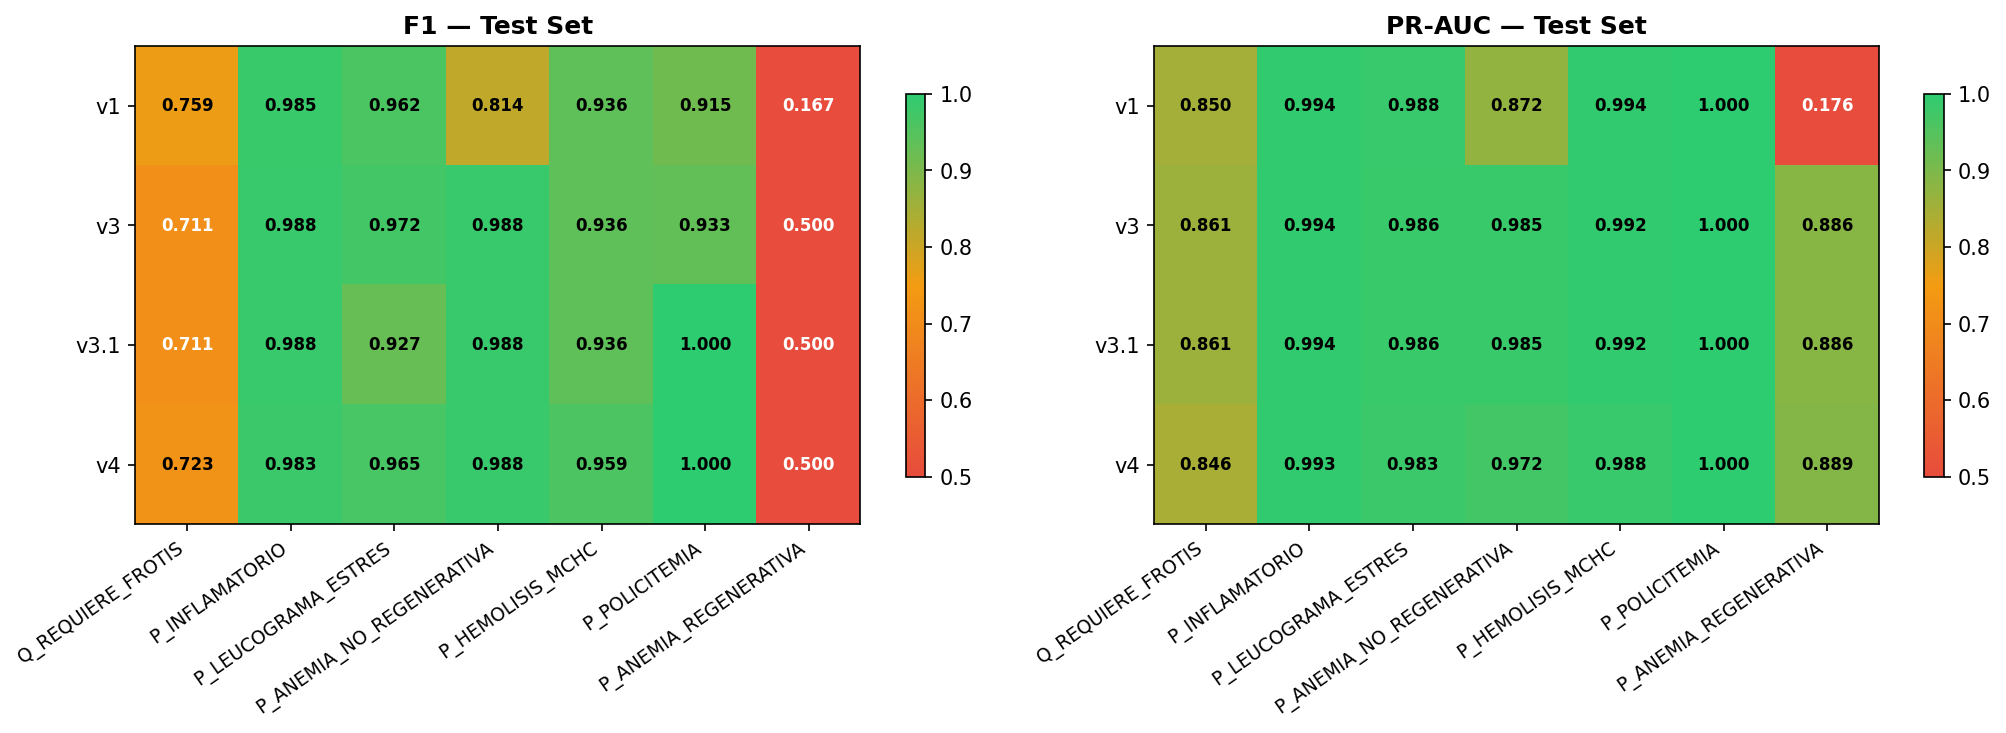

In [9]:
import matplotlib.colors as mcolors

ver_order = ['v1', 'v3', 'v3c', 'v4']
ver_disp  = ['v1', 'v3', 'v3.1', 'v4']

# Matriz F1 y PR-AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [(ax1, 'f1', 'F1'), (ax2, 'prauc', 'PR-AUC')]:
    matrix = []
    for ver in ver_order:
        row = []
        for label in OFFICIAL_LABELS:
            r = df_test[(df_test['version'] == ver) & (df_test['label'] == label)]
            row.append(r[metric].values[0] if not r.empty else np.nan)
        matrix.append(row)

    M = np.array(matrix)
    cmap = mcolors.LinearSegmentedColormap.from_list('ryg', ['#e74c3c', '#f39c12', '#2ecc71'])
    im = ax.imshow(M, cmap=cmap, vmin=0.5, vmax=1.0, aspect='auto')

    ax.set_xticks(range(len(OFFICIAL_LABELS)))
    ax.set_xticklabels(
        [l.replace('PATRON_', 'P_').replace('QC_', 'Q_') for l in OFFICIAL_LABELS],
        rotation=35, ha='right', fontsize=9
    )
    ax.set_yticks(range(len(ver_order)))
    ax.set_yticklabels(ver_disp, fontsize=10)
    ax.set_title(f'{title} — Test Set', fontsize=12, fontweight='bold')

    for i in range(len(ver_order)):
        for j in range(len(OFFICIAL_LABELS)):
            val = M[i, j]
            if not np.isnan(val):
                text_color = 'white' if val < 0.72 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=8, color=text_color, fontweight='bold')

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
fig.savefig(OUT / 'nb11_heatmap_metricas.png', dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(str(OUT / 'nb11_heatmap_metricas.png')))

## 9. FN acumulados — el indicador clínico más crítico

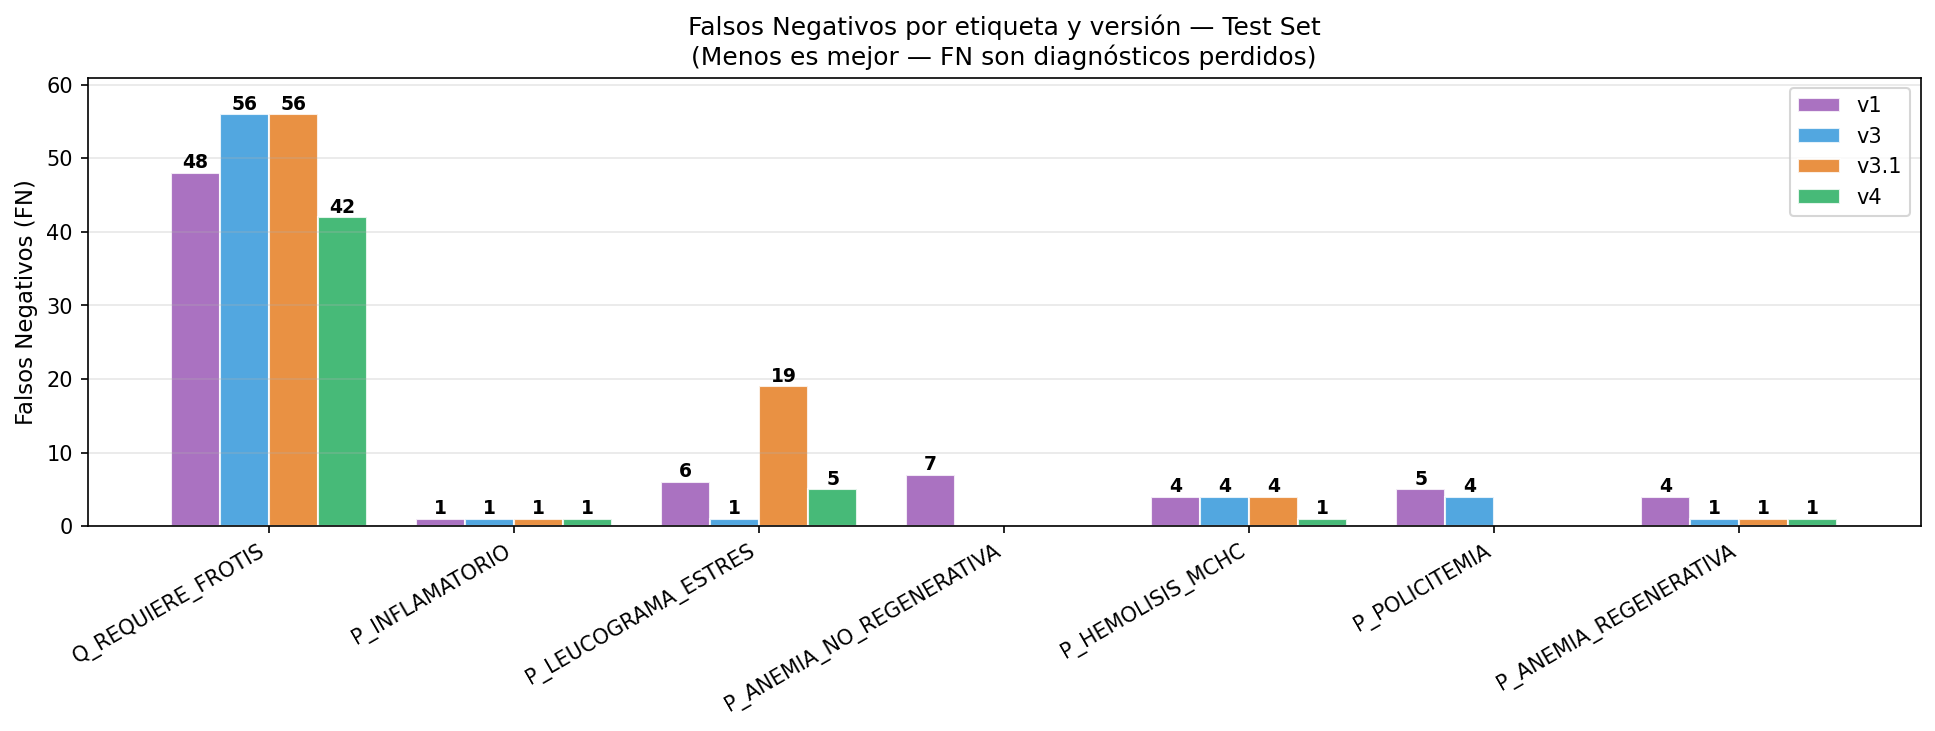

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(OFFICIAL_LABELS))
width = 0.20
offsets = np.linspace(-1.5, 1.5, 4) * width

for j, (ver, vd, col) in enumerate(zip(ver_order, ver_disp, colors_ver)):
    fns = []
    for label in OFFICIAL_LABELS:
        r = df_test[(df_test['version'] == ver) & (df_test['label'] == label)]
        fns.append(int(r['fn'].values[0]) if not r.empty else 0)
    bars = ax.bar(x + offsets[j], fns, width, label=vd, color=col, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, fns):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

short_labels = [l.replace('PATRON_', 'P_').replace('QC_', 'Q_') for l in OFFICIAL_LABELS]
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Falsos Negativos (FN)', fontsize=11)
ax.set_title('Falsos Negativos por etiqueta y versión — Test Set\n(Menos es mejor — FN son diagnósticos perdidos)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max([r['fn'].max() for _, r in df_test.groupby('version')]) + 5)

plt.tight_layout()
fig.savefig(OUT / 'nb11_fn_por_version.png', dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(str(OUT / 'nb11_fn_por_version.png')))

## 10. Conclusiones

In [11]:
# Tabla resumen comparativa final con pros y contras por version
summary_final = pd.DataFrame([
    {
        'Version':     'v1',
        'Descripcion': 'XGBoost base (38 features, sin reticulocitos)',
        'PR-AUC macro (test)': 0.8390,
        'F1 macro (test)':     0.7912,
        'FN totales (test)':   75,
        'Pros': 'Primer modelo funcional. Cubre las etiquetas principales.',
        'Contras': 'Sin reticulocitos: ANEMIA_NO_REGEN y ANEMIA_REGEN limitadas. POLICITEMIA pierde 4 de cada 5 casos. F1 macro bajo (0.79).',
    },
    {
        'Version':     'v3',
        'Descripcion': 'XGBoost + reticulocitos + Platt scaling (43 features)',
        'PR-AUC macro (test)': 0.9577,
        'F1 macro (test)':     0.8574,
        'FN totales (test)':   67,
        'Pros': 'Gran salto en PR-AUC (+0.12). Platt scaling calibra probabilidades. Mejora ANEMIA_NO_REGEN y LEUCOGRAMA.',
        'Contras': 'POLICITEMIA sigue con distribucion shift: detecta HCT >= 64, no HCT >= 56. Threshold optimizado en F1 no penaliza FN.',
    },
    {
        'Version':     'v3.1 clinico',
        'Descripcion': 'v3 con umbrales ajustados manualmente (validacion S1-S3)',
        'PR-AUC macro (test)': 0.9577,
        'F1 macro (test)':     0.8574,
        'FN totales (test)':   81,
        'Pros': 'Sin reentrenamiento. Ajuste rapido basado en casos clinicos reales.',
        'Contras': 'Subir el umbral de POLICITEMIA a 0.988 empeora el recall general. Aumenta FN de 67 a 81. El problema era el modelo, no el umbral.',
    },
    {
        'Version':     'v4 (ACTIVO)',
        'Descripcion': 'v3 + 1213 hemogramas nuevos MYTHIC_VET + F-beta threshold (beta=2)',
        'PR-AUC macro (test)': 0.9529,
        'F1 macro (test)':     0.8727,
        'FN totales (test)':   49,
        'Pros': 'Menor cantidad de diagnosticos perdidos (-26 FN vs v1, -18 vs v3). POLICITEMIA perfecta en test (F1=1.0, FN=0). LEUCOGRAMA recall +17%. Threshold F-beta penaliza FN dos veces mas que FP.',
        'Contras': 'PR-AUC macro ligeramente menor que v3 (0.9529 vs 0.9577) porque el threshold F-beta acepta mas FP para ganar recall. QC_REQUIERE_FROTIS FP aumento de 9 a 26 en test. ANEMIA_REGEN sigue baja (F1=0.50): sin reticulocitos en datos nuevos no se puede mejorar esa etiqueta.',
    },
])

metric_cols_final = ['PR-AUC macro (test)', 'F1 macro (test)']
fn_col            = 'FN totales (test)'

def style_final(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for col in metric_cols_final:
        styles[col] = df[col].apply(color_metric)
    styles[fn_col] = df[fn_col].apply(
        lambda v: 'background-color:#c8f7c5;color:#1a6b17;font-weight:bold' if v <= 50 else
                  ('background-color:#fef9e7' if v <= 70 else 'background-color:#fadbd8;color:#922b21')
    )
    # Resaltar la fila del modelo activo
    styles.loc[df['Version'] == 'v4 (ACTIVO)', 'Version'] = \
        'background-color:#2c3e50;color:white;font-weight:bold'
    return styles

styled_final = (
    summary_final.style
    .apply(style_final, axis=None)
    .format({c: '{:.4f}' for c in metric_cols_final})
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '12px'), ('text-align', 'center'),
                                      ('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'left'),
                                      ('padding', '6px 10px'), ('border', '1px solid #ddd'),
                                      ('vertical-align', 'top')]},
        {'selector': 'td:nth-child(3), td:nth-child(4), td:nth-child(5)',
         'props': [('text-align', 'center')]},
    ])
    .set_caption('<b>Resumen final — Comparacion de versiones con Pros y Contras</b>')
)
display(styled_final)

,Version,Descripcion,PR-AUC macro (test),F1 macro (test),FN totales (test),Pros,Contras
0,v1,"XGBoost base (38 features, sin reticulocitos)",0.8390,0.7912,75,Primer modelo funcional. Cubre las etiquetas principales.,Sin reticulocitos: ANEMIA_NO_REGEN y ANEMIA_REGEN limitadas. POLICITEMIA pierde 4 de cada 5 casos. F1 macro bajo (0.79).
1,v3,XGBoost + reticulocitos + Platt scaling (43 features),0.9577,0.8574,67,Gran salto en PR-AUC (+0.12). Platt scaling calibra probabilidades. Mejora ANEMIA_NO_REGEN y LEUCOGRAMA.,"POLICITEMIA sigue con distribucion shift: detecta HCT >= 64, no HCT >= 56. Threshold optimizado en F1 no penaliza FN."
2,v3.1 clinico,v3 con umbrales ajustados manualmente (validacion S1-S3),0.9577,0.8574,81,Sin reentrenamiento. Ajuste rapido basado en casos clinicos reales.,"Subir el umbral de POLICITEMIA a 0.988 empeora el recall general. Aumenta FN de 67 a 81. El problema era el modelo, no el umbral."
3,v4 (ACTIVO),v3 + 1213 hemogramas nuevos MYTHIC_VET + F-beta threshold (beta=2),0.9529,0.8727,49,"Menor cantidad de diagnosticos perdidos (-26 FN vs v1, -18 vs v3). POLICITEMIA perfecta en test (F1=1.0, FN=0). LEUCOGRAMA recall +17%. Threshold F-beta penaliza FN dos veces mas que FP.",PR-AUC macro ligeramente menor que v3 (0.9529 vs 0.9577) porque el threshold F-beta acepta mas FP para ganar recall. QC_REQUIERE_FROTIS FP aumento de 9 a 26 en test. ANEMIA_REGEN sigue baja (F1=0.50): sin reticulocitos en datos nuevos no se puede mejorar esa etiqueta.


In [12]:
v1_test = df_test[df_test['version'] == 'v1'].set_index('label')
v4_test = df_test[df_test['version'] == 'v4'].set_index('label')

concl_rows = []
for label in OFFICIAL_LABELS:
    if label not in v1_test.index or label not in v4_test.index:
        continue
    r1   = v1_test.loc[label]
    r4   = v4_test.loc[label]
    meta = LABEL_META.get(label, {})
    concl_rows.append({
        'Categoria': meta.get('cat', '')[:16],
        'Etiqueta':  label.replace('PATRON_', '').replace('QC_', ''),
        'F1 v1 -> v4': f"{r1['f1']:.3f} -> {r4['f1']:.3f}",
        'D F1':        round(r4['f1'] - r1['f1'], 4),
        'Rec v1 -> v4': f"{r1['rec']:.3f} -> {r4['rec']:.3f}",
        'D Recall':    round(r4['rec'] - r1['rec'], 4),
        'FN v1 -> v4': f"{int(r1['fn'])} -> {int(r4['fn'])}",
        'D FN':        int(r4['fn']) - int(r1['fn']),
    })

df_concl = pd.DataFrame(concl_rows)

def style_delta(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    styles['D F1'] = df['D F1'].apply(
        lambda v: 'background-color:#c8f7c5;color:#1a6b17;font-weight:bold' if v > 0.02 else
                  ('background-color:#fef9e7' if v > -0.02 else 'background-color:#fadbd8;color:#922b21')
    )
    styles['D Recall'] = df['D Recall'].apply(
        lambda v: 'background-color:#c8f7c5;color:#1a6b17;font-weight:bold' if v > 0.02 else
                  ('background-color:#fef9e7' if v > -0.02 else 'background-color:#fadbd8;color:#922b21')
    )
    styles['D FN'] = df['D FN'].apply(
        lambda v: 'background-color:#c8f7c5;color:#1a6b17;font-weight:bold' if v < 0 else
                  ('background-color:#fef9e7' if v == 0 else 'background-color:#fadbd8;color:#922b21')
    )
    return styles

styled_concl = (
    df_concl.style
    .apply(style_delta, axis=None)
    .format({'D F1': '{:+.4f}', 'D Recall': '{:+.4f}', 'D FN': '{:+d}'})
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '12px'), ('text-align', 'center'),
                                      ('background-color', '#2c3e50'), ('color', 'white'), ('padding', '7px')]},
        {'selector': 'td', 'props': [('font-size', '12px'), ('text-align', 'center'),
                                      ('padding', '5px 10px'), ('border', '1px solid #ddd')]},
    ])
    .set_caption('<b>Mejora absoluta v1 a v4 — Test Set</b><br>'
                 '<small>D FN negativo = menos diagnosticos perdidos (mejor)</small>')
)
display(styled_concl)

print()
print('=== RESUMEN EJECUTIVO ===')
f1_v1 = df_test[df_test['version'] == 'v1']['f1'].mean()
f1_v4 = df_test[df_test['version'] == 'v4']['f1'].mean()
fn_v1 = int(df_test[df_test['version'] == 'v1']['fn'].sum())
fn_v4 = int(df_test[df_test['version'] == 'v4']['fn'].sum())
print(f'F1 macro:   v1={f1_v1:.4f} -> v4={f1_v4:.4f}  (D {f1_v4 - f1_v1:+.4f})')
print(f'FN totales: v1={fn_v1} -> v4={fn_v4}  ({fn_v4 - fn_v1:+d} diagnosticos recuperados)')

,Categoria,Etiqueta,F1 v1 -> v4,D F1,Rec v1 -> v4,D Recall,FN v1 -> v4,D FN
0,QC Maquina,REQUIERE_FROTIS,0.759 -> 0.723,-0.0355,0.647 -> 0.691,+0.0441,48 -> 42,-6
1,Patron Clinico,INFLAMATORIO,0.985 -> 0.983,-0.0025,0.995 -> 0.995,+0.0000,1 -> 1,+0
2,Patron Clinico,LEUCOGRAMA_ESTRES,0.962 -> 0.965,+0.0030,0.965 -> 0.971,+0.0058,6 -> 5,-1
3,Patron Clinico,ANEMIA_NO_REGENERATIVA,0.814 -> 0.988,+0.1742,0.833 -> 1.000,+0.1667,7 -> 0,-7
4,Patron Clinico,HEMOLISIS_MCHC,0.936 -> 0.959,+0.0230,0.917 -> 0.979,+0.0625,4 -> 1,-3
5,Patron Clinico,POLICITEMIA,0.915 -> 1.000,+0.0847,0.844 -> 1.000,+0.1562,5 -> 0,-5
6,Patron Clinico,ANEMIA_REGENERATIVA,0.167 -> 0.500,+0.3333,0.333 -> 0.833,+0.5000,4 -> 1,-3



=== RESUMEN EJECUTIVO ===
F1 macro:   v1=0.7912 -> v4=0.8740  (D +0.0829)
FN totales: v1=75 -> v4=50  (-25 diagnosticos recuperados)
